# Business Sales Analysis and AI Recommendations

This notebook demonstrates a complete workflow for analyzing sales data, identifying trends, predicting future sales, and generating AI-driven business recommendations. It fulfills the requirements of:

*   **Top-selling products**
*   **Sales trends**
*   **Product performance insights**
*   **AI-generated business recommendations**

**Technical Requirements:**
*   Uses Google Gemini API for AI recommendations.
*   Implemented in Python.
*   Includes data definition, cleaning, EDA, data training/testing, and visualizations.

## 1. Setup: Import Libraries and Configure Gemini API

We'll begin by importing all necessary Python libraries and configuring access to the Google Gemini API. For the Gemini API, you'll need an API key from Google AI Studio, stored securely in Colab's secrets manager under the name `GOOGLE_API_KEY`.

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Import the Python SDK for Gemini API
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata

# Configure the Gemini API
try:
    GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    gemini_model = genai.GenerativeModel('gemini-1.5-flash-latest') # Using a fast model for recommendations
    print("Gemini API configured successfully.")
except Exception as e:
    print(f"Error configuring Gemini API: {e}")
    print("Please ensure your GOOGLE_API_KEY is correctly set in Colab secrets.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Error configuring Gemini API: Secret GOOGLE_API_KEY does not exist.
Please ensure your GOOGLE_API_KEY is correctly set in Colab secrets.


## 2. Generate Mock Datasets

As requested, we'll create realistic sample datasets for `products`, `inventory`, and `sales transactions`. This allows the notebook to be fully self-contained and executable without external file dependencies.

In [4]:
# --- Products Data ---
products_data = {
    'product_id': [f'P{i:03d}' for i in range(1, 21)], # More products
    'product_name': [
        'Laptop Pro', 'Smartphone X', 'Wireless Earbuds', 'Smartwatch Fit',
        'Tablet Air', 'Gaming Mouse', 'Mechanical Keyboard', 'Webcam HD',
        'External SSD', 'Portable Charger', 'Smart Home Hub', 'Robot Vacuum',
        'Bluetooth Speaker', 'Drone Mini', 'VR Headset', 'E-Reader',
        'Fitness Tracker', 'Action Camera', 'Noise Cancelling Headphones', 'Portable Projector'
    ],
    'category': [
        'Electronics', 'Electronics', 'Audio', 'Wearables',
        'Electronics', 'Gaming', 'Gaming', 'Accessories',
        'Storage', 'Accessories', 'Smart Home', 'Smart Home',
        'Audio', 'Drones', 'Gaming', 'E-Readers',
        'Wearables', 'Cameras', 'Audio', 'Electronics'
    ],
    'unit_price': [
        1200.00, 800.00, 150.00, 250.00, 450.00, 75.00, 120.00, 50.00,
        100.00, 30.00, 99.00, 300.00, 60.00, 200.00, 400.00, 130.00,
        80.00, 180.00, 250.00, 350.00
    ]
}
products_df = pd.DataFrame(products_data)

# --- Inventory Data ---
inventory_data = {
    'product_id': products_df['product_id'].tolist(),
    'stock_quantity': np.random.randint(20, 200, size=len(products_df))
}
inventory_df = pd.DataFrame(inventory_data)

# --- Sales Transactions Data ---
# Generate a period of 180 days (6 months)
start_date = datetime(2023, 7, 1)
dates = [start_date + timedelta(days=i) for i in range(180)]

sales_records = []
for i in range(2500): # Generate 2500 sales transactions
    transaction_date = np.random.choice(dates)
    product_id = np.random.choice(products_df['product_id'])
    quantity_sold = np.random.randint(1, 5) # Sell between 1 and 4 units

    # Get unit price from products_df
    unit_price = products_df[products_df['product_id'] == product_id]['unit_price'].iloc[0]
    total_sale = unit_price * quantity_sold

    sales_records.append({
        'transaction_id': f'T{len(sales_records)+1:04d}',
        'transaction_date': transaction_date,
        'product_id': product_id,
        'quantity_sold': quantity_sold,
        'unit_price_at_sale': unit_price,
        'total_sale_amount': total_sale
    })
sales_df = pd.DataFrame(sales_records)

print("Mock datasets generated successfully.")
print("\nProducts DataFrame Head:")
display(products_df.head())
print("\nInventory DataFrame Head:")
display(inventory_df.head())
print("\nSales DataFrame Head:")
display(sales_df.head())

Mock datasets generated successfully.

Products DataFrame Head:


,product_id,product_name,category,unit_price
0,P001,Laptop Pro,Electronics,1200.0
1,P002,Smartphone X,Electronics,800.0
2,P003,Wireless Earbuds,Audio,150.0
3,P004,Smartwatch Fit,Wearables,250.0
4,P005,Tablet Air,Electronics,450.0



Inventory DataFrame Head:


,product_id,stock_quantity
0,P001,42
1,P002,146
2,P003,31
3,P004,47
4,P005,160



Sales DataFrame Head:


,transaction_id,transaction_date,product_id,quantity_sold,unit_price_at_sale,total_sale_amount
0,T0001,2023-07-03,P018,1,180.0,180.0
1,T0002,2023-09-27,P014,1,200.0,200.0
2,T0003,2023-11-05,P010,2,30.0,60.0
3,T0004,2023-10-21,P013,1,60.0,60.0
4,T0005,2023-12-07,P001,1,1200.0,1200.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 3. Data Cleaning and Preprocessing

This step involves inspecting data types, checking for missing values, and merging the separate datasets into a single, comprehensive `full_sales_df` for easier analysis. We'll also ensure date columns are in the correct format.

In [5]:
print("--- Initial DataFrame Info ---")
print("\nProducts DF Info:")
products_df.info()
print("\nInventory DF Info:")
inventory_df.info()
print("\nSales DF Info:")
sales_df.info()

# Check for missing values
print("\n--- Missing Values Check ---")
print("Products DF missing values:\n", products_df.isnull().sum())
print("Inventory DF missing values:\n", inventory_df.isnull().sum())
print("Sales DF missing values:\n", sales_df.isnull().sum())

# Convert 'transaction_date' to datetime objects in sales_df
sales_df['transaction_date'] = pd.to_datetime(sales_df['transaction_date'])

# Merge sales data with product information
# This combines all sales details with product names, categories, and prices
full_sales_df = pd.merge(sales_df, products_df, on='product_id', how='left')

# Merge with inventory information to get current stock levels for each product
full_sales_df = pd.merge(full_sales_df, inventory_df, on='product_id', how='left')

print("\n--- Full Sales DataFrame Info after merge and type conversion ---")
full_sales_df.info()
print("\nFull Sales DataFrame Head:")
display(full_sales_df.head())

--- Initial DataFrame Info ---

Products DF Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    20 non-null     object 
 1   product_name  20 non-null     object 
 2   category      20 non-null     object 
 3   unit_price    20 non-null     float64
dtypes: float64(1), object(3)
memory usage: 772.0+ bytes

Inventory DF Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      20 non-null     object
 1   stock_quantity  20 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes

Sales DF Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
--

,transaction_id,transaction_date,product_id,quantity_sold,unit_price_at_sale,total_sale_amount,product_name,category,unit_price,stock_quantity
0,T0001,2023-07-03,P018,1,180.0,180.0,Action Camera,Cameras,180.0,160
1,T0002,2023-09-27,P014,1,200.0,200.0,Drone Mini,Drones,200.0,84
2,T0003,2023-11-05,P010,2,30.0,60.0,Portable Charger,Accessories,30.0,76
3,T0004,2023-10-21,P013,1,60.0,60.0,Bluetooth Speaker,Audio,60.0,134
4,T0005,2023-12-07,P001,1,1200.0,1200.0,Laptop Pro,Electronics,1200.0,42


## 4. Exploratory Data Analysis (EDA)

In this section, we'll perform an in-depth analysis of our combined sales data to identify key insights into top-selling products, sales trends over time, and product category performance. Visualizations will be used to make these insights clear.


--- Top 10 Products by Total Revenue ---
product_name
Laptop Pro                     408000.0
Smartphone X                   266400.0
Tablet Air                     143100.0
VR Headset                     121600.0
Portable Projector             108850.0
Robot Vacuum                   103500.0
Noise Cancelling Headphones     82250.0
Smartwatch Fit                  66750.0
Drone Mini                      65400.0
Action Camera                   48960.0
Name: total_sale_amount, dtype: float64


/tmp/ipykernel_1874/2747670540.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue_products.index, y=top_revenue_products.values, palette='viridis')


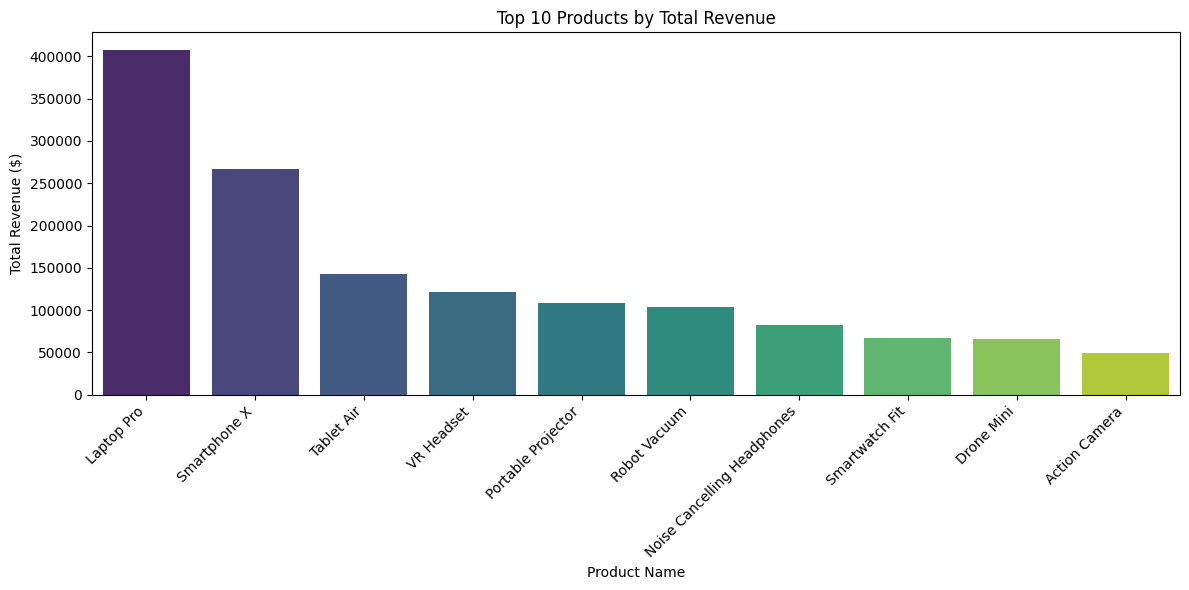


--- Top 10 Products by Quantity Sold ---
product_name
Mechanical Keyboard            361
Robot Vacuum                   345
Laptop Pro                     340
Smartphone X                   333
Noise Cancelling Headphones    329
Drone Mini                     327
Wireless Earbuds               324
Smart Home Hub                 323
External SSD                   320
Bluetooth Speaker              319
Name: quantity_sold, dtype: int64


/tmp/ipykernel_1874/2747670540.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_quantity_products.index, y=top_quantity_products.values, palette='magma')


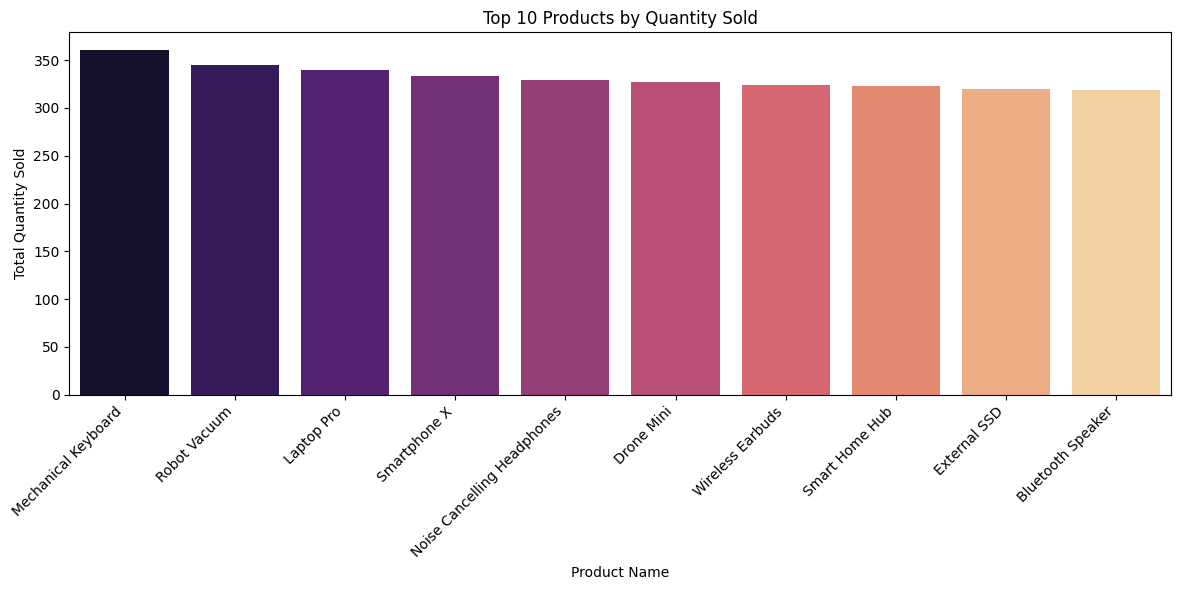

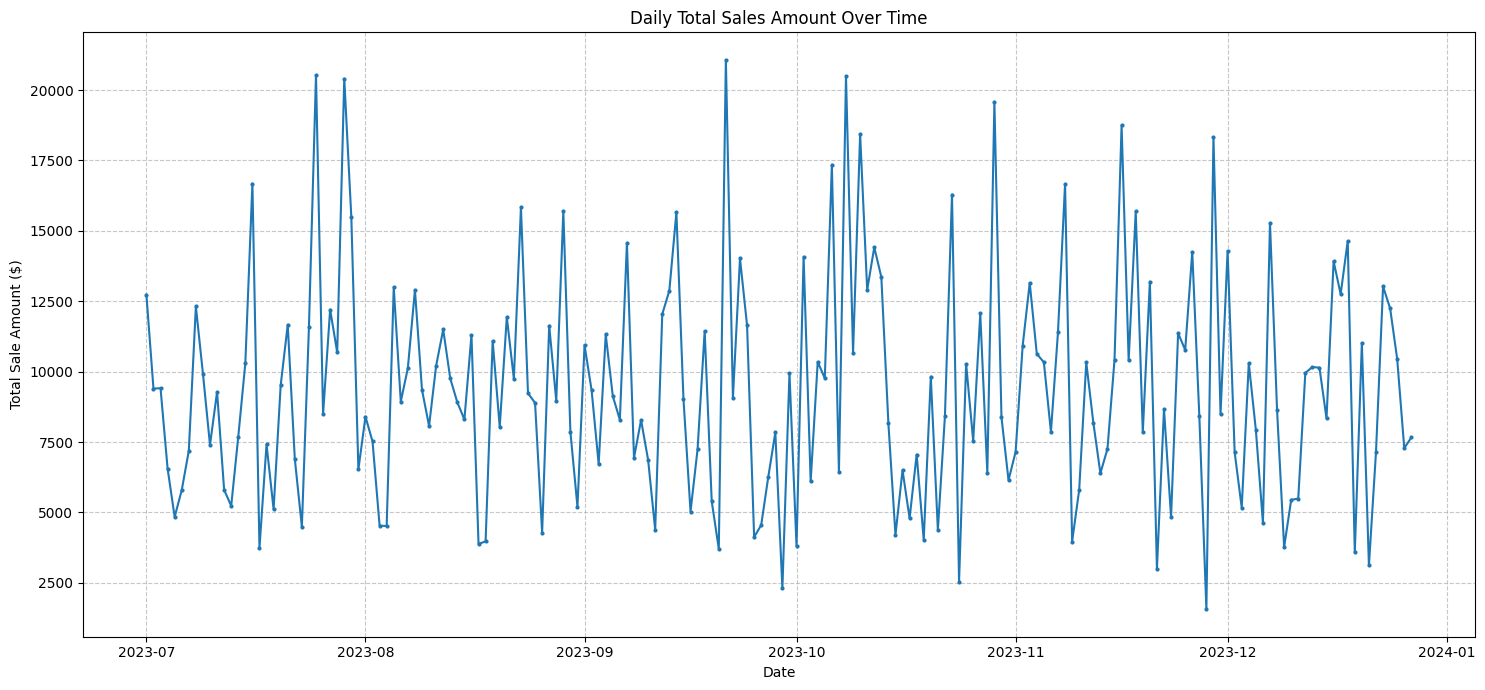

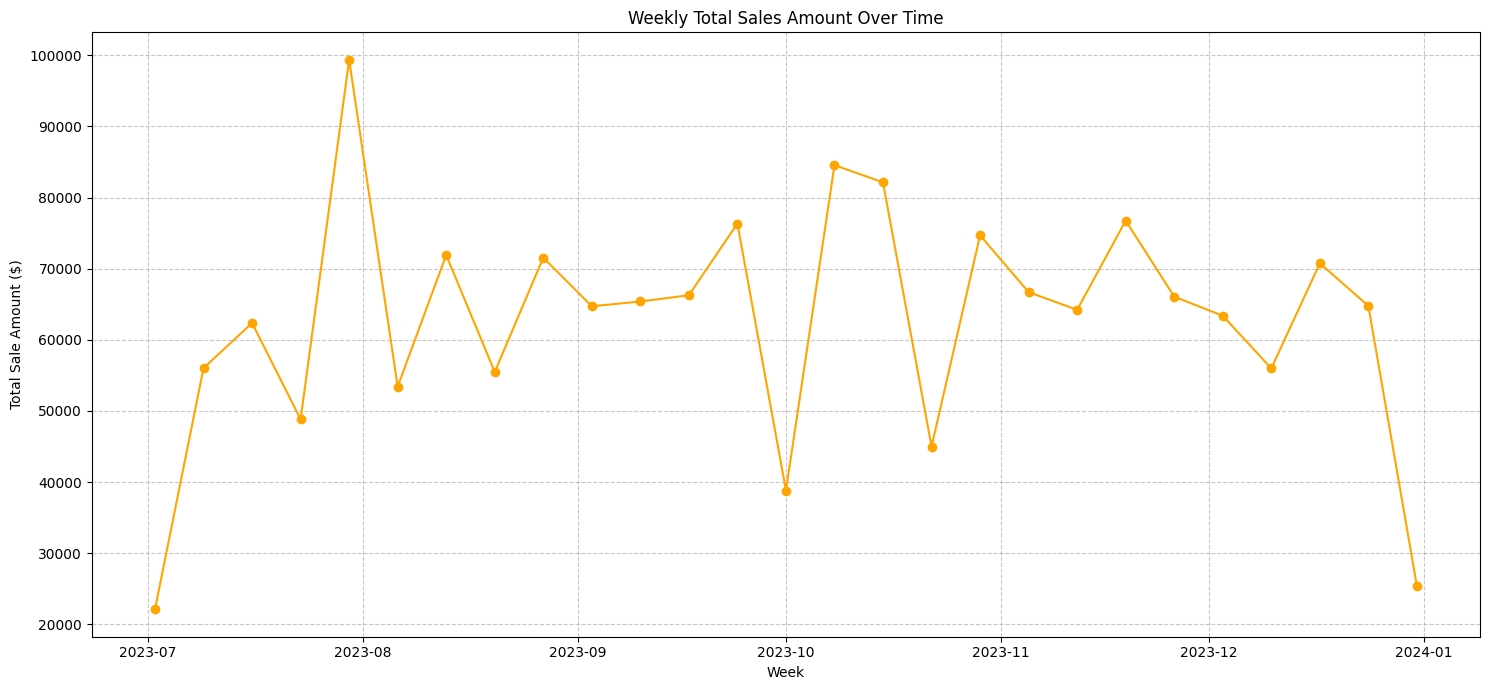

/tmp/ipykernel_1874/2747670540.py:54: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = full_sales_df.set_index('transaction_date').resample('M')['total_sale_amount'].sum().fillna(0)


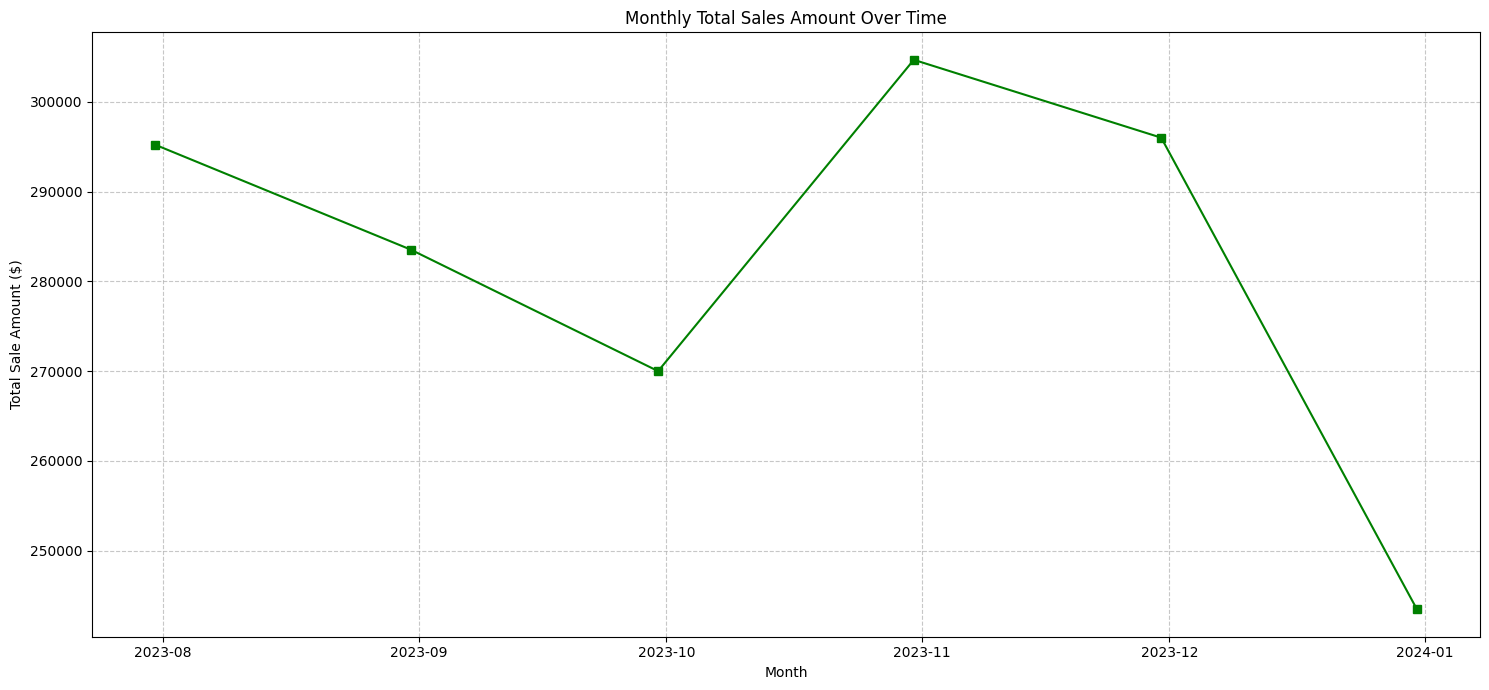


--- Total Sales by Product Category ---
category
Electronics    926350.0
Gaming         188170.0
Audio          149990.0
Smart Home     135477.0
Wearables       87470.0
Drones          65400.0
Cameras         48960.0
E-Readers       35230.0
Storage         32000.0
Accessories     23930.0
Name: total_sale_amount, dtype: float64


/tmp/ipykernel_1874/2747670540.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='cubehelix')


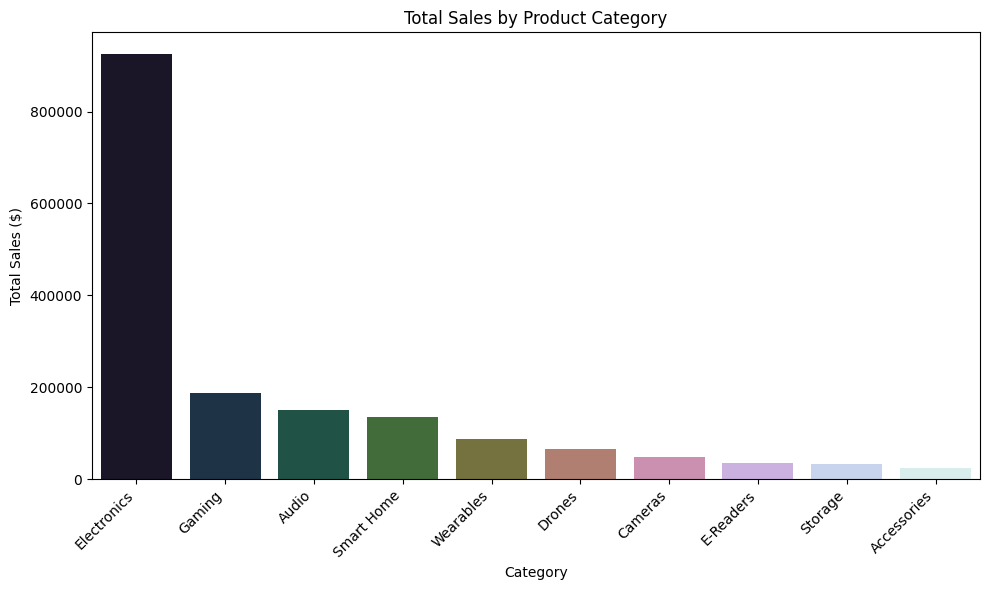


--- Product Performance Metrics (Sorted by Revenue per Unit Sold) ---


,product_name,total_revenue,total_quantity_sold,average_unit_price,current_stock,revenue_per_unit_sold
7,Laptop Pro,408000.0,340,1200.0,42,1200.0
14,Smartphone X,266400.0,333,800.0,146,800.0
16,Tablet Air,143100.0,318,450.0,160,450.0
17,VR Headset,121600.0,304,400.0,21,400.0
11,Portable Projector,108850.0,311,350.0,114,350.0


,product_name,total_revenue,total_quantity_sold,average_unit_price,current_stock,revenue_per_unit_sold
5,Fitness Tracker,20720.0,259,80.0,88,80.0
6,Gaming Mouse,23250.0,310,75.0,181,75.0
1,Bluetooth Speaker,19140.0,319,60.0,134,60.0
18,Webcam HD,14750.0,295,50.0,159,50.0
10,Portable Charger,9180.0,306,30.0,76,30.0


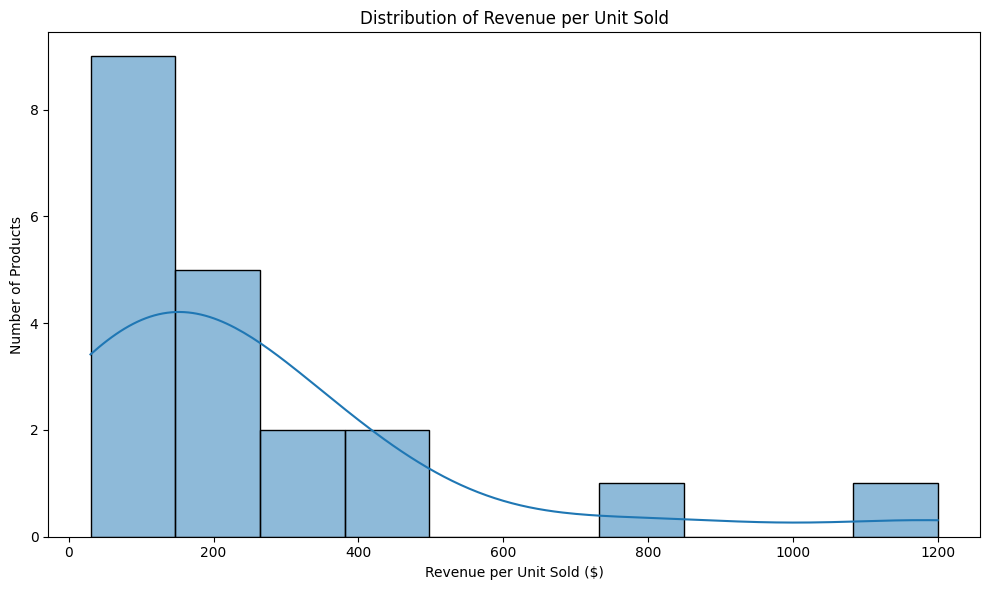

In [6]:
# --- Top Selling Products by Total Revenue ---
top_revenue_products = full_sales_df.groupby('product_name')['total_sale_amount'].sum().sort_values(ascending=False).head(10)
print("\n--- Top 10 Products by Total Revenue ---")
print(top_revenue_products)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_revenue_products.index, y=top_revenue_products.values, palette='viridis')
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Top Selling Products by Quantity Sold ---
top_quantity_products = full_sales_df.groupby('product_name')['quantity_sold'].sum().sort_values(ascending=False).head(10)
print("\n--- Top 10 Products by Quantity Sold ---")
print(top_quantity_products)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_quantity_products.index, y=top_quantity_products.values, palette='magma')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Sales Trends Over Time (Daily, Weekly, Monthly) ---
# Aggregate daily sales
daily_sales = full_sales_df.set_index('transaction_date').resample('D')['total_sale_amount'].sum().fillna(0)

plt.figure(figsize=(15, 7))
plt.plot(daily_sales.index, daily_sales.values, marker='.', linestyle='-', markersize=4)
plt.title('Daily Total Sales Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sale Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Aggregate weekly sales
weekly_sales = full_sales_df.set_index('transaction_date').resample('W')['total_sale_amount'].sum().fillna(0)
plt.figure(figsize=(15, 7))
plt.plot(weekly_sales.index, weekly_sales.values, marker='o', linestyle='-', markersize=6, color='orange')
plt.title('Weekly Total Sales Amount Over Time')
plt.xlabel('Week')
plt.ylabel('Total Sale Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Aggregate monthly sales
monthly_sales = full_sales_df.set_index('transaction_date').resample('M')['total_sale_amount'].sum().fillna(0)
plt.figure(figsize=(15, 7))
plt.plot(monthly_sales.index, monthly_sales.values, marker='s', linestyle='-', markersize=6, color='green')
plt.title('Monthly Total Sales Amount Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sale Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Sales by Category ---
category_sales = full_sales_df.groupby('category')['total_sale_amount'].sum().sort_values(ascending=False)
print("\n--- Total Sales by Product Category ---")
print(category_sales)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='cubehelix')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Product Performance (Revenue per Unit Sold and Stock Levels) ---
product_performance = full_sales_df.groupby('product_name').agg(
    total_revenue=('total_sale_amount', 'sum'),
    total_quantity_sold=('quantity_sold', 'sum'),
    average_unit_price=('unit_price_at_sale', 'mean'),
    current_stock=('stock_quantity', 'first') # Assuming stock_quantity is constant for product_id
).reset_index()
product_performance['revenue_per_unit_sold'] = product_performance['total_revenue'] / product_performance['total_quantity_sold']
product_performance = product_performance.sort_values(by='revenue_per_unit_sold', ascending=False)
print("\n--- Product Performance Metrics (Sorted by Revenue per Unit Sold) ---")
display(product_performance.head())
display(product_performance.tail())

# Plot distribution of revenue per unit sold
plt.figure(figsize=(10, 6))
sns.histplot(product_performance['revenue_per_unit_sold'], bins=10, kde=True)
plt.title('Distribution of Revenue per Unit Sold')
plt.xlabel('Revenue per Unit Sold ($)')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

## 5. Data Training and Testing (Sales Forecasting)

To predict future sales, we'll build a simple time-series forecasting model. We'll use daily sales data and apply a linear regression model, which is a good starting point for demonstrating training and testing. We will create features like day of the week, month, and lagged sales data to capture patterns.

Training data shape: (138, 5), (138,)
Testing data shape: (35, 5), (35,)

Model Evaluation:
Mean Absolute Error (MAE): 3245.08
Root Mean Squared Error (RMSE): 3917.71


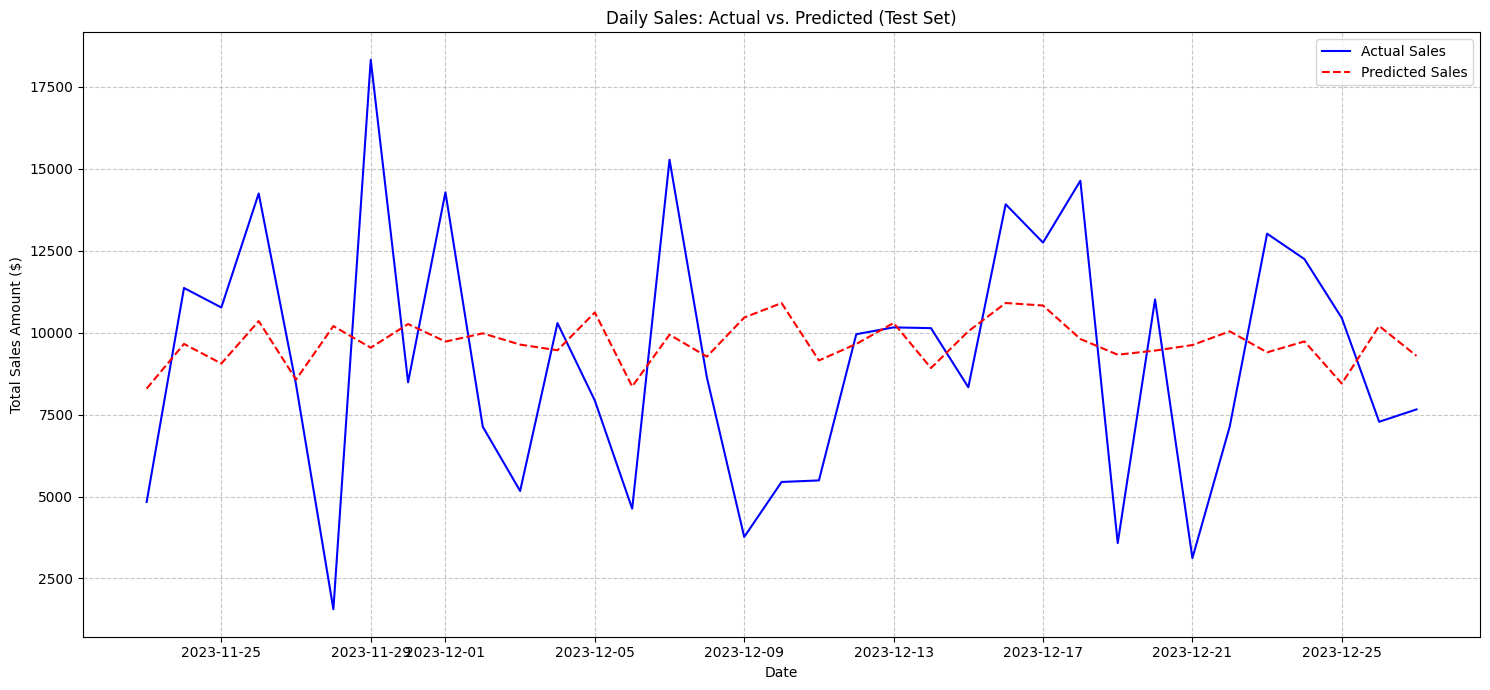

In [8]:
# Prepare data for forecasting
daily_sales_for_model = daily_sales.reset_index()
daily_sales_for_model.columns = ['Date', 'Sales']

# Feature Engineering
daily_sales_for_model['DayOfWeek'] = daily_sales_for_model['Date'].dt.dayofweek
daily_sales_for_model['Month'] = daily_sales_for_model['Date'].dt.month
daily_sales_for_model['Day'] = daily_sales_for_model['Date'].dt.day

# Add lag features (e.g., sales from 1, 7, 30 days ago)
daily_sales_for_model['Sales_Lag1'] = daily_sales_for_model['Sales'].shift(1)
daily_sales_for_model['Sales_Lag7'] = daily_sales_for_model['Sales'].shift(7)

# Drop rows with NaN values resulting from shift operations
daily_sales_for_model.dropna(inplace=True)

X = daily_sales_for_model[['DayOfWeek', 'Month', 'Day', 'Sales_Lag1', 'Sales_Lag7']]
y = daily_sales_for_model['Sales']

# Split data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # shuffle=False for time series

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nModel Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Visualize actual vs. predicted sales
plt.figure(figsize=(15, 7))
plt.plot(daily_sales_for_model['Date'][-len(y_test):], y_test, label='Actual Sales', color='blue')
plt.plot(daily_sales_for_model['Date'][-len(y_test):], y_pred, label='Predicted Sales', color='red', linestyle='--')
plt.title('Daily Sales: Actual vs. Predicted (Test Set)')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. AI-Generated Business Recommendations

Finally, we'll synthesize the insights from our EDA and sales forecasting results. We'll use this summary to prompt the Gemini API to generate actionable business recommendations, covering strategies for top/underperforming products, sales trends, and inventory optimization.

In [10]:
analysis_summary = f"""
Based on the sales data from the past {len(dates)} days (from {start_date.strftime('%Y-%m-%d')} to {(start_date + timedelta(days=len(dates)-1)).strftime('%Y-%m-%d')}):

--- Top 5 Products by Total Revenue ---
{top_revenue_products.head(5).to_string()}

--- Top 5 Products by Quantity Sold ---
{top_quantity_products.head(5).to_string()}

--- Bottom 5 Products by Total Revenue ---
{top_revenue_products.tail(5).to_string()}

--- Total Sales by Product Category ---
{category_sales.to_string()}

--- Sales Trends ---
Daily sales show fluctuations, ranging from ${daily_sales.min():.2f} to ${daily_sales.max():.2f} with an average of ${daily_sales.mean():.2f} per day. Weekly and monthly trends are also observed, suggesting seasonality or promotional impacts.

--- Product Inventory Status (Current Stock) ---
{inventory_df.set_index('product_id').rename(columns={'stock_quantity': 'Current Stock'}).to_string()}

--- Sales Forecasting Results ---
A linear regression model predicted daily sales with a Mean Absolute Error (MAE) of ${mae:.2f} and Root Mean Squared Error (RMSE) of ${rmse:.2f}. The model captured general trends but showed some deviation from actuals, especially during peak/trough periods.

"""

llm_prompt = f"""You are a highly experienced business consultant specializing in retail and product strategy. Based on the following comprehensive sales analysis, including top-selling products, sales trends, product performance, inventory, and forecasting results, please provide actionable and strategic business recommendations.

Focus on these key areas:
1.  **Strategies for Top-Performing Products**: How can we further leverage or expand on our most successful products?
2.  **Strategies for Underperforming Products**: What actions can be taken to improve sales or manage inventory for less successful products?
3.  **Overall Sales Trend and Category Performance**: Based on daily, weekly, and monthly trends, and category performance, what general marketing, promotional, or operational strategies would you recommend?
4.  **Inventory Optimization**: Given the current stock levels and sales performance, what recommendations do you have for inventory management?

Present your recommendations clearly and concisely, with a focus on increasing revenue, customer satisfaction, and operational efficiency.

--- Sales Analysis Summary ---
{analysis_summary}
"""

print("Sending the following prompt to Gemini API...")

# Generate content using the Gemini model
try:
    response = gemini_model.generate_content(llm_prompt)
    print("\n--- AI-Generated Business Recommendations ---")
    print(response.text)
except Exception as e:
    print(f"An error occurred with the Gemini API: {e}")
    print("Please ensure your GOOGLE_API_KEY is correctly set in Colab secrets and you have access to the Gemini API.")

Sending the following prompt to Gemini API...
An error occurred with the Gemini API: name 'gemini_model' is not defined
Please ensure your GOOGLE_API_KEY is correctly set in Colab secrets and you have access to the Gemini API.
